In [1]:
from astroML.datasets import generate_mu_z
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor, kernels
from sklearn.gaussian_process.kernels import ConstantKernel, RBF
from scipy.optimize import fmin_cobyla
import numpy as np
from astropy.cosmology import FlatLambdaCDM
import emcee
import corner.corner

<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
C:\Users\User\AppData\Local\Temp\ipykernel_26356\224906477.py:5: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mu$")


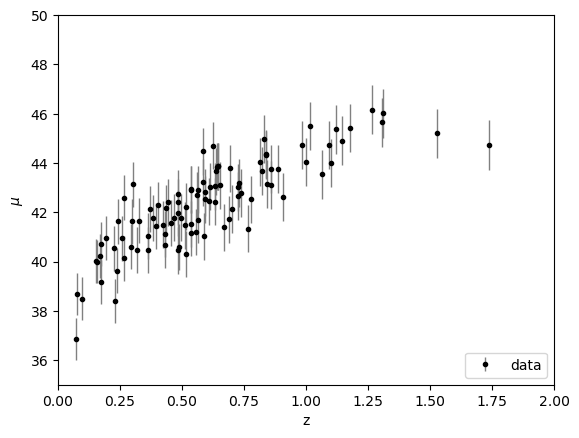

In [3]:
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) ###YOU CAN'T CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

In [5]:
z_sample
mu_sample
dmu

array([0.91862497, 0.95818624, 0.94340343, 0.97222794, 0.97171179,
       0.92819662, 0.92860378, 0.97385018, 0.9966678 , 0.98218018,
       0.93649091, 0.948558  , 0.96318467, 0.9656542 , 0.93760835,
       0.95334492, 0.94872528, 0.86485225, 0.97103496, 0.98306194,
       0.93712847, 0.95764923, 0.89710554, 0.93748105, 0.99104229,
       0.96054687, 0.93997207, 0.97255426, 0.93265984, 0.95389152,
       0.98131431, 0.94327408, 0.97387777, 0.91153822, 0.96493354,
       0.96496076, 0.92210777, 0.98951197, 0.94376982, 0.98691576,
       0.89231065, 0.91764268, 0.88762944, 0.96247275, 0.95599473,
       0.95113453, 0.88588283, 0.95336368, 0.93388642, 0.94871596,
       0.90572161, 0.95699473, 0.95372094, 0.85295833, 0.95781273,
       0.98736141, 0.97272887, 1.01211963, 0.99684655, 0.97286954,
       0.92951505, 0.95841129, 0.94671347, 0.91917738, 0.93867591,
       0.89019692, 0.94455508, 1.00520951, 0.9080577 , 0.90719541,
       0.96790571, 0.95541351, 0.94618927, 0.90474131, 0.92335

In [7]:
#start with generating model 

$$\mu = 5 \log \left( \frac{c/H_0} {10 {\rm pc}}(1+z)\int_0^z \frac{dz'}{\sqrt{\Omega_m (1+z^3)+\Omega_\Lambda}} \right) $$

in a flat universe:
$$
\mu(z)=5\log_{10}\left[
\frac{c/H_0}{10\,\mathrm{pc}}
(1+z)
\int_0^z
\frac{dz'}
{\sqrt{\Omega_m(1+z')^3 + (1-\Omega_m)}}
\right]
$$

In [10]:
#model to describe data 
#theta rapresents the parameter 
def mu_model(theta, z_data):
    H_0, omega_m = theta #parameter definition 
    cosmo = FlatLambdaCDM(H0=H_0,Om0=omega_m)

    return cosmo.distmod(z_data).value

In [12]:
#to avoid problem, better to work with log like, log prior and log posterior 
def log_like(theta, z_data, mu_data, sigma_mu):
    H_0, omega_m = theta #parameter definition 
    analitical_model = mu_model(theta,z_data)
    
    return -0.5*np.sum((mu_data-analitical_model)**2/sigma_mu**2)

In [14]:
def ln_priors(theta, low, up):
    H_0, omega_m = theta #parameter definition
    for i, fp in enumerate (theta):
        if fp < low[i] or fp > up[i]:
            return -np.inf
    return 0.0

In [16]:
def log_posterior(theta, low, up, z_data, mu_data, sigma_mu):
    H_0, omega_m = theta #parameter definition
    prior = ln_priors(theta, low, up)
    if np.isfinite(prior):
        return prior + log_like(theta, z_data,mu_data,sigma_mu)
    else:
        return prior

In [18]:
ndim = 2  # number of parameters in the model
nwalkers = 10  # number of MCMC walkers
nsteps = 10000  # number of MCMC steps to take **for each walker**

low_extreme = np.array([50,0.01]) 
up_extreme = np.array([100,1])

starting_guesses = low_extreme +1e-1*np.random.randn(nwalkers, ndim)

In [20]:
test_val = log_posterior([60,0.5],low_extreme, up_extreme, z_sample,mu_sample, dmu)
print(test_val)

-48.24558611152023


In [22]:
sampler = emcee.EnsembleSampler(nwalkers,ndim,log_posterior,args=(low_extreme , up_extreme, z_sample, mu_sample, dmu)) #call a function, in args i don't pass theta
sampler.run_mcmc(starting_guesses, nsteps)

C:\Users\User\anaconda3\Lib\site-packages\emcee\moves\red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


State([[60.28988401  0.67529581]
 [66.56036663  0.44333476]
 [58.70271441  0.75064064]
 [57.67025533  0.52031603]
 [57.86766232  0.83069941]
 [77.41637975  0.08871463]
 [74.31709214  0.18892161]
 [70.08114453  0.2759556 ]
 [63.65428041  0.64751821]
 [64.23504614  0.37603692]], log_prob=[-46.87014967 -46.42256479 -47.10440809 -50.01733085 -47.13187853
 -46.95168963 -46.6293739  -46.41015838 -46.70293544 -47.1497386 ], blobs=None, random_state=('MT19937', array([2169780011, 1513697612,   15321434,  898247734, 3008050992,
       1165278710, 1001982680, 3811929915,  192479950, 2436973867,
       3018058040, 3508386640,  434158918, 2641497452, 2390530175,
       4044002645, 1240601392, 2852077101, 2656243814,  252415123,
       1972133193, 3302343268,   17978105, 1898836453,  400291463,
       3456933443, 1179812355, 4048867291,  366247284, 1510414094,
        462431766, 2719055591,  435879345, 2488452830,   69688738,
       3732404228, 2689352906, 3549705071,  962789624, 1626665647,
      

Text(0.5, 0, 'number of steps')

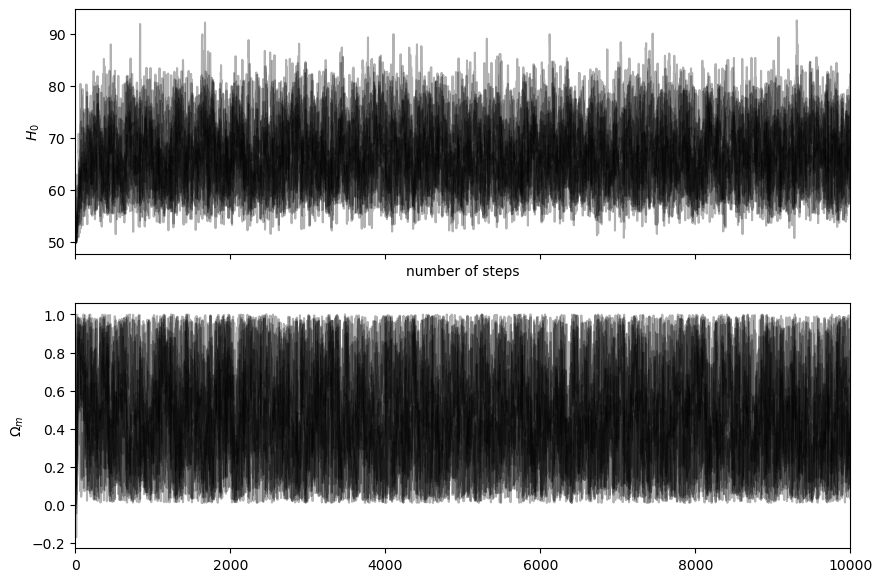

In [24]:
samples = sampler.get_chain()
    
fig, axes = plt.subplots(2, figsize=(10,7), sharex = True)

labels = [r"$H_0$", r"$\Omega_m$"]

for i in range(2):
    ax = axes[i]
    ax.plot(samples[:,:,i], "k", alpha = 0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    
axes[0].set_xlabel("number of steps")

In [26]:
tau = sampler.get_autocorr_time() #how many time do I take to have a sample that is independent from the previous one 
#burnin = int(2 * np.max(tau)) #or maybe three, in general watch the parameter you have
print(tau)

[41.18032875 40.06607895]


In [28]:
#need to discard the burn in point to thin the chain 
flat_samples = sampler.get_chain(discard=100, thin=30, flat=True) 
print(flat_samples.shape)

(3300, 2)


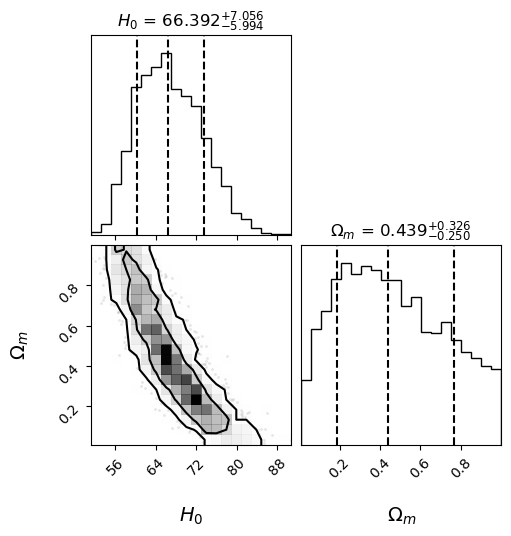

In [30]:
#what is the precision I estimate quantile
fig = corner.corner(
    flat_samples,
    labels=labels,
    show_titles=True,
    title_fmt=".3f",
    quantiles=[0.16, 0.5, 0.84],
    levels=[0.68, 0.95], #credible level
    title_kwargs={"fontsize": 12},
    label_kwargs={"fontsize": 14},
    plot_contours=True
)

<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\m'
C:\Users\User\AppData\Local\Temp\ipykernel_26356\4110408603.py:4: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mu$")


(35.0, 50.0)

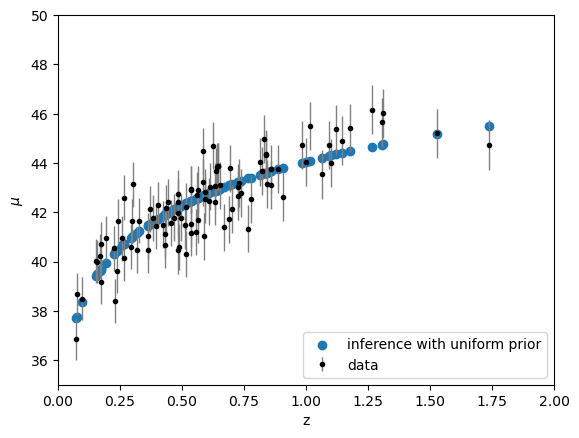

In [32]:
plt.scatter(z_sample, mu_model((66.606, 0.431), z_sample), label = "inference with uniform prior") 
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

### case of a model without dark energy ($\Omega_m = 1$)

In [35]:
def mu_model_new(theta, z_data):
    H_0= float(theta)  #parameter definition 
    cosmo = FlatLambdaCDM(H0=H_0,Om0=1)

    return cosmo.distmod(z_data).value

In [37]:
#to avoid problem, better to work with log like, log prior and log posterior 
def log_like_new(theta, z_data, mu_data, sigma_mu):
    H_0 = float(theta)  #parameter definition 
    analitical_model = mu_model_new(theta,z_data)
    
    return -0.5*np.sum((mu_data-analitical_model)**2/sigma_mu**2)

In [39]:
def ln_priors_new(theta, low, up):
    H_0 = float(theta) #parameter definition
    if theta < low or theta > up:
        return -np.inf
    return 0.0

In [41]:
def log_posterior_new(theta, low, up, z_data, mu_data, sigma_mu):
    H_0 = float(theta)  #parameter definition
    prior = ln_priors_new(theta, low, up)
    if np.isfinite(prior):
        return prior + log_like_new(theta, z_data,mu_data,sigma_mu)
    else:
        return prior

In [43]:
ndim = 1  # number of parameters in the model
nwalkers = 20  # number of MCMC walkers
nsteps = 10000  # number of MCMC steps to take **for each walker**

low_extreme = 50
up_extreme = 100

starting_guesses = low_extreme +1e-1*np.random.randn(nwalkers, ndim)

In [45]:
test_val = log_posterior_new(60,low_extreme, up_extreme, z_sample,mu_sample, dmu)
print(test_val)

-47.53894260415179


In [47]:
sampler_new = emcee.EnsembleSampler(nwalkers,ndim,log_posterior_new,args=(low_extreme , up_extreme, z_sample, mu_sample, dmu)) #call a function, in args i don't pass theta
sampler_new.run_mcmc(starting_guesses, nsteps)

C:\Users\User\AppData\Local\Temp\ipykernel_26356\938871033.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  H_0 = float(theta)  #parameter definition
C:\Users\User\AppData\Local\Temp\ipykernel_26356\31779455.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  H_0 = float(theta)  #parameter definition
C:\Users\User\anaconda3\Lib\site-packages\emcee\moves\red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


State([[58.58853872]
 [58.4439456 ]
 [58.19987477]
 [58.11271062]
 [55.39687876]
 [55.03948243]
 [57.12238529]
 [58.15969396]
 [59.04479156]
 [62.25249392]
 [56.84437506]
 [62.70111157]
 [56.38733138]
 [59.62402743]
 [59.65898747]
 [55.91700477]
 [54.30285372]
 [58.62416706]
 [54.588102  ]
 [61.44157515]], log_prob=[-47.17745031 -47.1570438  -47.12982587 -47.1223236  -47.50551947
 -47.65004623 -47.1209594  -47.12622175 -47.26242881 -48.68790152
 -47.14895315 -48.99511578 -47.22283536 -47.41445834 -47.4251859
 -47.33581181 -48.02176248 -47.18296425 -47.86585292 -48.19706267], blobs=None, random_state=('MT19937', array([2463170695, 3294494223, 1594442093, 2886361108, 2668696234,
        736929124, 3944378590, 3514302243, 4198219148, 2971284312,
       1902747185,  111898380, 1842420832, 2688190834, 4202529027,
       3824665404, 2187015971,  470524736, 1621481868,  868299923,
       3011120409,   70801925, 4271883067, 2336056997,  981325353,
       1439845809,  341518889, 3353980237, 195

Text(0.5, 0, 'number of steps')

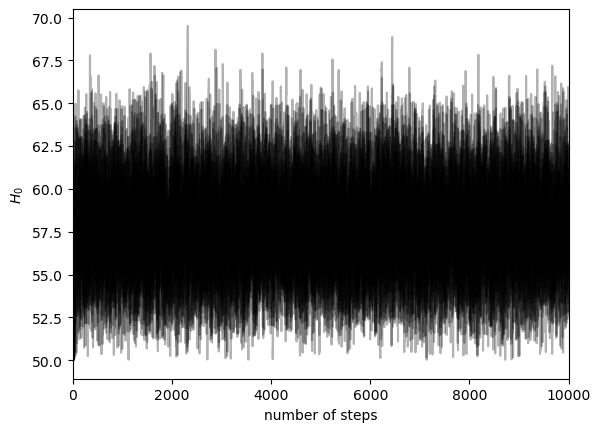

In [49]:
samples_new = sampler_new.get_chain()
plt.plot(samples_new[:,:,0], "k", alpha = 0.3)
plt.xlim(0, len(samples_new))
plt.ylabel(r"$H_0$")
plt.xlabel("number of steps")

In [51]:
tau_new = sampler_new.get_autocorr_time() #how many time do I take to have a sample that is independent from the previous one 
#burnin = int(2 * np.max(tau)) #or maybe three, in general watch the parameter you have
print(tau_new)

[28.832684]


In [53]:
#need to discard the burn in point to thin the chain 
flat_samples_new = sampler_new.get_chain(discard=90, thin=30, flat=True) 
print(flat_samples_new.shape)

(6600, 1)


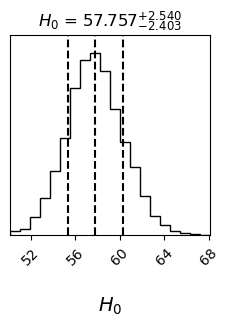

In [55]:
#what is the precision I estimate quantile
fig = corner.corner(
    flat_samples_new,
    labels=[r"$H_0$"],
    show_titles=True,
    title_fmt=".3f",
    quantiles=[0.16, 0.5, 0.84],
    levels=[0.68, 0.95], #credible level
    title_kwargs={"fontsize": 12},
    label_kwargs={"fontsize": 14},
    plot_contours=True
)

<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
C:\Users\User\AppData\Local\Temp\ipykernel_26356\2494699514.py:5: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mu$")


(35.0, 50.0)

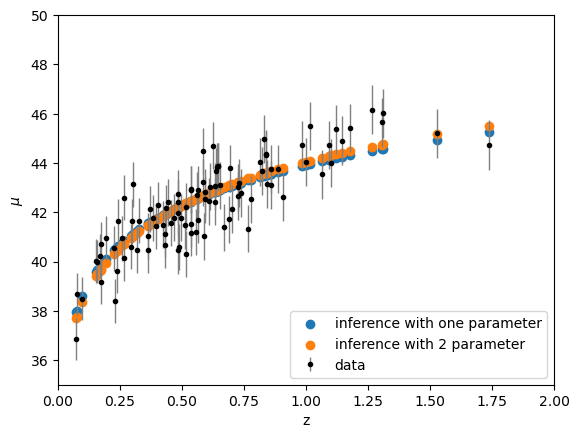

In [57]:
plt.scatter(z_sample, mu_model_new(57.739, z_sample), label = "inference with one parameter") 
plt.scatter(z_sample, mu_model((66.606, 0.431), z_sample), label = "inference with 2 parameter")
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)